In [1]:
import ssl
from pathlib import Path
from urllib.error import URLError
from urllib.request import urlopen

DOWNLOAD_DIR = Path("D:/RPS/mldownload")
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

RPS_URL = "https://storage.googleapis.com/learning-datasets/rps.zip"
RPS_TEST_URL = "https://storage.googleapis.com/learning-datasets/rps-test-set.zip"
RPS_ZIP = DOWNLOAD_DIR / "rps.zip"
RPS_TEST_ZIP = DOWNLOAD_DIR / "rps-test-set.zip"

def download_file(url, destination):
    if destination.exists() and destination.stat().st_size > 0:
        print(f"File already exists, skipping: {destination}")
        return

    temp_path = destination.with_suffix(destination.suffix + ".part")
    print(f"Downloading: {url}")

    try:
        response = urlopen(url, timeout=120)
    except URLError:
        context = ssl._create_unverified_context()
        response = urlopen(url, timeout=120, context=context)

    with response, temp_path.open("wb") as file:
        while True:
            data = response.read(1024 * 1024)
            if not data:
                break
            file.write(data)

    temp_path.replace(destination)
    size_mb = destination.stat().st_size / 1024 / 1024
    print(f"Downloaded: {destination} ({size_mb:.1f} MB)")

download_file(RPS_URL, RPS_ZIP)
download_file(RPS_TEST_URL, RPS_TEST_ZIP)


Downloading: https://storage.googleapis.com/learning-datasets/rps.zip
Downloaded: D:\RPS\mldownload\rps.zip (191.4 MB)
Downloading: https://storage.googleapis.com/learning-datasets/rps-test-set.zip
Downloaded: D:\RPS\mldownload\rps-test-set.zip (28.1 MB)


In [2]:
import zipfile

def extract_zip(zip_path, extract_dir):
    if not zip_path.exists():
        raise FileNotFoundError(f"Zip file not found. Run the download cell first: {zip_path}")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        bad_file = zip_ref.testzip()
        if bad_file is not None:
            raise zipfile.BadZipFile(
                f"Zip file looks corrupted at {bad_file}. Delete {zip_path} and download again."
            )
        zip_ref.extractall(extract_dir)

    print(f"Extracted: {zip_path} -> {extract_dir}")

extract_zip(RPS_ZIP, DOWNLOAD_DIR)
extract_zip(RPS_TEST_ZIP, DOWNLOAD_DIR)


Extracted: D:\RPS\mldownload\rps.zip -> D:\RPS\mldownload
Extracted: D:\RPS\mldownload\rps-test-set.zip -> D:\RPS\mldownload


In [3]:
rock_dir = DOWNLOAD_DIR / "rps" / "rock"
paper_dir = DOWNLOAD_DIR / "rps" / "paper"
scissors_dir = DOWNLOAD_DIR / "rps" / "scissors"

for image_dir in [rock_dir, paper_dir, scissors_dir]:
    if not image_dir.exists():
        raise FileNotFoundError(
            f"Directory not found: {image_dir}. Run the download and extract cells first."
        )

rock_files = sorted(path.name for path in rock_dir.iterdir())
paper_files = sorted(path.name for path in paper_dir.iterdir())
scissors_files = sorted(path.name for path in scissors_dir.iterdir())

print("total training rock images:", len(rock_files))
print("total training paper images:", len(paper_files))
print("total training scissors images:", len(scissors_files))

print(rock_files[:10])
print(paper_files[:10])
print(scissors_files[:10])


total training rock images: 840
total training paper images: 840
total training scissors images: 840
['rock01-000.png', 'rock01-001.png', 'rock01-002.png', 'rock01-003.png', 'rock01-004.png', 'rock01-005.png', 'rock01-006.png', 'rock01-007.png', 'rock01-008.png', 'rock01-009.png']
['paper01-000.png', 'paper01-001.png', 'paper01-002.png', 'paper01-003.png', 'paper01-004.png', 'paper01-005.png', 'paper01-006.png', 'paper01-007.png', 'paper01-008.png', 'paper01-009.png']
['scissors01-000.png', 'scissors01-001.png', 'scissors01-002.png', 'scissors01-003.png', 'scissors01-004.png', 'scissors01-005.png', 'scissors01-006.png', 'scissors01-007.png', 'scissors01-008.png', 'scissors01-009.png']


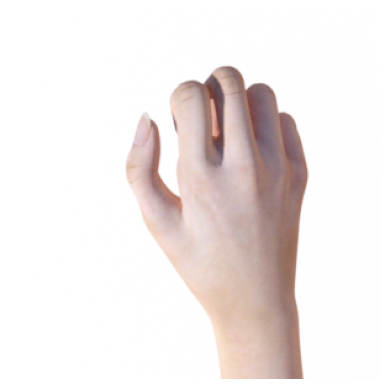

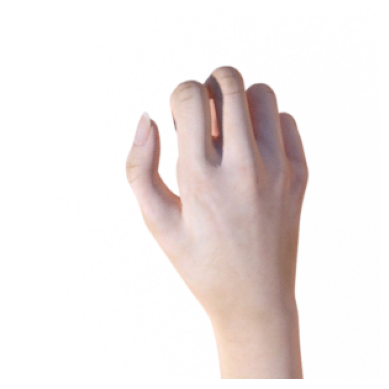

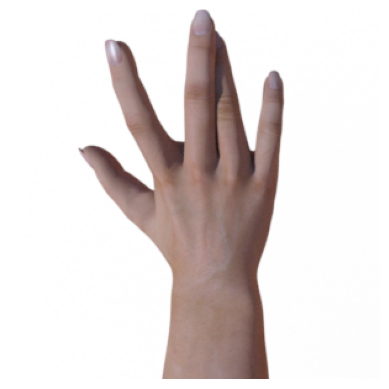

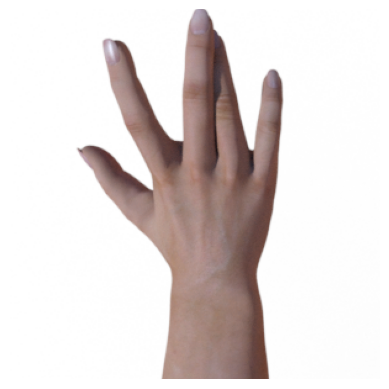

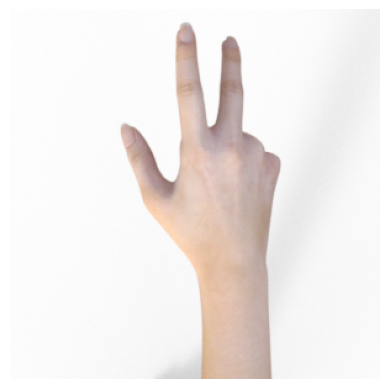

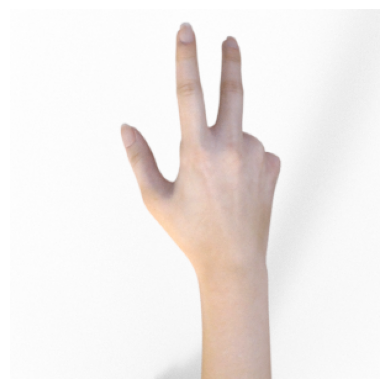

In [5]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pic_index = 2

next_rock = [rock_dir / fname for fname in rock_files[pic_index - 2:pic_index]]
next_paper = [paper_dir / fname for fname in paper_files[pic_index - 2:pic_index]]
next_scissors = [scissors_dir / fname for fname in scissors_files[pic_index - 2:pic_index]]

for img_path in next_rock + next_paper + next_scissors:
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()


In [13]:
import tensorflow as tf

from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAINING_DIR = "D:/RPS/mldownload/rps/"
training_datagen = ImageDataGenerator(
      rescale = 1./255,
	    rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

VALIDATION_DIR = "D:/RPS/mldownload/rps-test-set/"
validation_datagen = ImageDataGenerator(rescale = 1./255)

train_generator = training_datagen.flow_from_directory(
	TRAINING_DIR,
	target_size=(150,150),
	class_mode='categorical',
  batch_size=126
)

validation_generator = validation_datagen.flow_from_directory(
	VALIDATION_DIR,
	target_size=(150,150),
	class_mode='categorical',
  batch_size=126
)

model = tf.keras.models.Sequential([
    # Note the input shape is the desired size of the image 150x150 with 3 bytes color
    # This is the first convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    # The second convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The third convolution
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The fourth convolution
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])


model.summary()

model.compile(loss = 'categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

history = model.fit(train_generator, epochs=25, steps_per_epoch=20, validation_data = validation_generator, verbose = 1, validation_steps=3)

model.save("rps.h5")


Found 2520 images belonging to 3 classes.
Found 372 images belonging to 3 classes.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,473,475 (13.25 MB)

 Trainable params: 3,473,475 (13.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.3528 - loss: 1.1186 - val_accuracy: 0.3333 - val_loss: 1.0878
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.3794 - loss: 1.1022 - val_accuracy: 0.3333 - val_loss: 1.1463
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.4413 - loss: 1.0680 - val_accuracy: 0.5242 - val_loss: 0.8492
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.5190 - loss: 0.9791 - val_accuracy: 0.7473 - val_loss: 0.6039
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.5964 - loss: 0.8535 - val_accuracy: 0.6828 - val_loss: 0.5900
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.6615 - loss: 0.7302 - val_accuracy: 0.9731 - val_loss: 0.3652
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.7190 - loss: 0.6265 - val_accuracy: 0.7823 - val_loss: 0.3844
Epoch 8/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.7575 - loss: 0.5652 - val_accuracy: 0.6452 - val_loss:

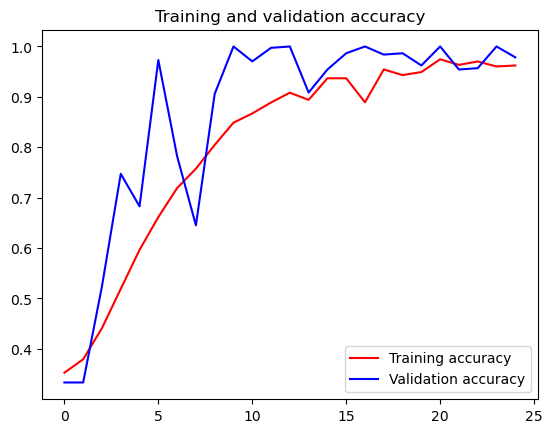

<Figure size 640x480 with 0 Axes>

In [14]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()
plt.show()


d:\Anaconda_envs\envs\tf_new\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda_envs\envs\tf_new\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


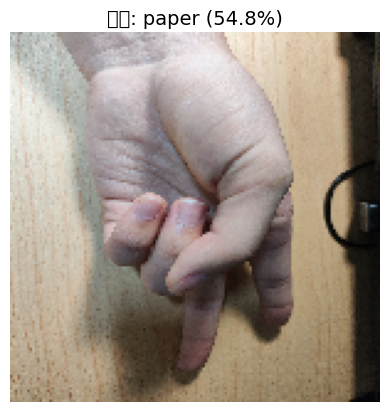

各类别概率:
  paper: 54.82%
  rock: 5.23%
  scissors: 39.96%


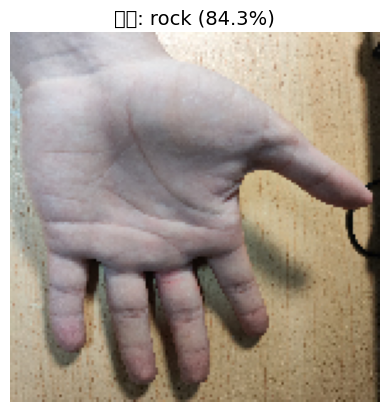

各类别概率:
  paper: 9.98%
  rock: 84.29%
  scissors: 5.74%


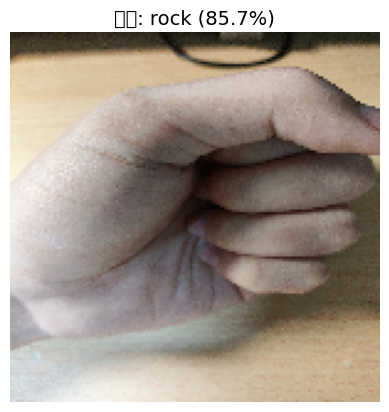

各类别概率:
  paper: 5.60%
  rock: 85.65%
  scissors: 8.75%


('rock', np.float32(85.653725))

In [1]:
# 模型测试 — 使用自己的图片

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from pathlib import Path

# 加载已保存的模型
model = tf.keras.models.load_model("rps.h5")

# 类别名称（按字母顺序，与训练时 flow_from_directory 一致）
class_names = ['paper', 'rock', 'scissors']

def predict_image(img_path):
    """预测单张图片并显示结果"""
    # 加载并预处理
    img = image.load_img(img_path, target_size=(150, 150))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # 预测
    predictions = model.predict(img_batch, verbose=0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0]) * 100

    # 显示图片和预测结果
    plt.imshow(img_array)
    plt.axis('off')
    plt.title(f"预测: {predicted_class} ({confidence:.1f}%)", fontsize=14)
    plt.show()

    # 打印各类别概率
    print("各类别概率:")
    for cls, prob in zip(class_names, predictions[0]):
        print(f"  {cls}: {prob*100:.2f}%")

    return predicted_class, confidence

# ============================================================
# 👇 修改这里的路径为你自己的图片路径
# ============================================================
image_path1 = "D:\\qqAndWX\\jd.jpg"
predict_image(image_path1)
# ============================================================
# 预测并显示结果
image_path2 = "D:\\qqAndWX\\bu.jpg"
predict_image(image_path2)

# ============================================================
image_path3 = "D:\\qqAndWX\\stone.jpg"
predict_image(image_path3)
